In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorSegmentacionTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y)).astype(np.int32)
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            mask_one_hot = tf.one_hot(parche_Y, depth=self.num_clases, dtype=tf.float32).numpy()
            
            batch_X.append(parche_X)
            batch_Y.append(mask_one_hot)
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, 48, 48, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

carpeta_dataset = r"D:\TFG\dataset_parches_50x50"
todos_los_X_total = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)
archivos_prueba = todos_los_X_total[:150000]

archivos_train, archivos_val = train_test_split(archivos_prueba, test_size=0.2, random_state=42)

generador_train = GeneradorSegmentacionTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorSegmentacionTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)

def build_unet_autoencoder(input_shape, num_classes):
    entradas = layers.Input(shape=input_shape)
    
    init = 'he_normal'
    reg = tf.keras.regularizers.l2(1e-6)
    
    x = layers.Normalization(axis=-1)(entradas)
    
    # ENCODER
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(x)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Cuello de botella
    bottleneck = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p2)
    bottleneck = layers.BatchNormalization()(bottleneck)
    bottleneck = layers.Activation('gelu')(bottleneck)
    
    # DECODER
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(bottleneck)
    merge3 = layers.concatenate([u3, c2]) 
    c3 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('gelu')(c3)
    
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(c3)
    merge4 = layers.concatenate([u4, c1]) 
    c4 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('gelu')(c4)
    
    salidas = layers.Conv2D(num_classes, (1, 1), activation='softmax', kernel_initializer=init)(c4)
    
    return models.Model(inputs=entradas, outputs=salidas)

model = build_unet_autoencoder((48, 48, 4), 19)

def dice_loss_multiclass(y_true, y_pred):
    y_pred = tf.nn.softmax(y_pred, axis=-1)
    
    smooth = 1e-5
    
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    area_true = tf.reduce_sum(y_true, axis=[1, 2])
    area_pred = tf.reduce_sum(y_pred, axis=[1, 2])
    
    dice_coef = (2.0 * intersection + smooth) / (area_true + area_pred + smooth)
    
    return 1.0 - tf.reduce_mean(dice_coef)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipvalue=0.5),
    loss=dice_loss_multiclass, 
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=40,
    callbacks=mis_callbacks
)

Epoch 1/40
 589/1875 [========>.....................] - ETA: 17:37 - loss: 0.9936 - accuracy: 0.3782

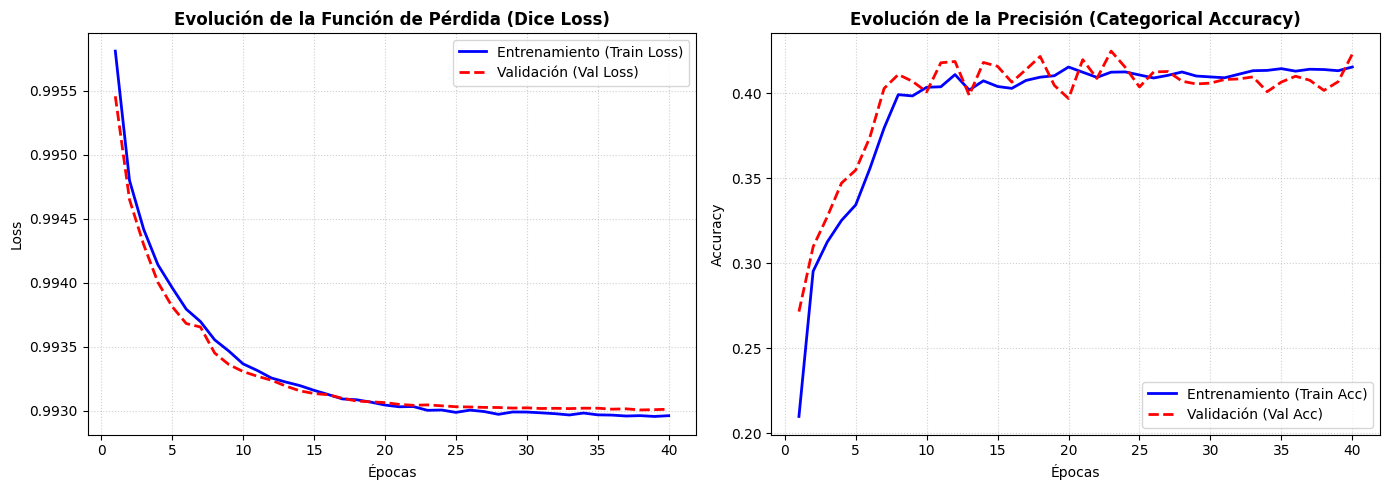

In [17]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño del gráfico con un estilo limpio
plt.figure(figsize=(14, 5))
epochs = range(1, len(history.history['loss']) + 1)

# --- GRÁFICO 1: LOSS (PÉRDIDA) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-', label='Entrenamiento (Train Loss)', linewidth=2)
plt.plot(epochs, history.history['val_loss'], 'r--', label='Validación (Val Loss)', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Dice Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# --- GRÁFICO 2: ACCURACY (PRECISIÓN) ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'b-', label='Entrenamiento (Train Acc)', linewidth=2)
plt.plot(epochs, history.history['val_accuracy'], 'r--', label='Validación (Val Acc)', linewidth=2)
plt.title('Evolución de la Precisión (Categorical Accuracy)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# 2. Ajustar espacios y guardar la imagen para la memoria del TFG
plt.tight_layout()
plt.savefig('curvas_entrenamiento_tfg.png', dpi=300) # Se guarda automáticamente en alta calidad
plt.show()